# Notebook 5: Baseline Classifiers
## kNN & Decision Tree for Resume Job Category Prediction

This notebook implements supervised classification baselines:
1. **Feature matrix construction**: Binary skill indicators + TF-IDF features
2. **k-Nearest Neighbors (kNN)** classifier with hyperparameter tuning
3. **Decision Tree** classifier with interpretability analysis
4. **Cross-validation** and statistical comparison
5. **Feature importance analysis**: Which skills drive classification?

These baselines let us compare structured modular reasoning (our multi-agent system) against traditional predictive models.


In [ ]:
from google.colab import drive
import os

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Define your actual Drive project path
drive_path = '/content/drive/MyDrive/Colab Notebooks/DM_project_1'

# 3. Create the symbolic links
# This links the 'data', 'models', and 'outputs' folders from Drive to your local Colab env
folders = ['data', 'models', 'outputs']

for folder in folders:
    source = os.path.join(drive_path, folder)
    link = f'/content/{folder}'

    # Remove existing local folder/link if it exists to avoid errors
    if os.path.exists(link) or os.path.islink(link):
        !rm -rf {link}

    # Create the link (Shortcut)
    !ln -s "{source}" "{link}"
    print(f"✅ Linked local '{folder}/' to Drive '{folder}/'")

Mounted at /content/drive
✅ Linked local 'data/' to Drive 'data/'
✅ Linked local 'models/' to Drive 'models/'
✅ Linked local 'outputs/' to Drive 'outputs/'


In [ ]:
# ============================================================
# Setup
# ============================================================
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load data
df_resumes = pd.read_csv('data/processed/resumes_with_skills.csv')
with open('data/processed/column_config.json') as f:
    col_config = json.load(f)
with open('data/processed/skill_category_map.json') as f:
    skill_category_map = json.load(f)
with open('data/processed/embeddings_data.pkl', 'rb') as f:
    emb_data = pickle.load(f)

cat_col = col_config['resume_cat_col']
df_resumes['skills_list'] = df_resumes['extracted_skills'].apply(json.loads)

print(f"Loaded {len(df_resumes)} resumes")
print(f"Categories: {df_resumes[cat_col].nunique()}")
print(df_resumes[cat_col].value_counts())


Loaded 106 resumes
Categories: 15
Category
Java Developer               13
Database                     11
Data Science                 10
DotNet Developer              7
Hadoop                        7
DevOps Engineer               7
Automation Testing            7
Testing                       7
Python Developer              6
Business Analyst              6
SAP Developer                 6
ETL Developer                 5
Network Security Engineer     5
Blockchain                    5
Web Designing                 4
Name: count, dtype: int64


## 1. Feature Matrix Construction

We build a structured feature vector for each resume using:
- **Binary skill indicators**: 1/0 for each canonical skill
- **Skill counts**: Frequency of each skill mention
- **Category-level features**: Count of skills per category
- **TF-IDF features**: From the full-text vectorizer

This multi-representation approach tests whether our extracted skill features capture meaningful job-related distinctions.


In [ ]:
# ============================================================
# 1. Build Feature Matrix
# ============================================================

# Get all unique canonical skills across the dataset
all_skills_flat = []
for skills in df_resumes['skills_list']:
    all_skills_flat.extend(skills)
unique_skills = sorted(set(all_skills_flat))
print(f"Unique skills across all resumes: {len(unique_skills)}")

# 1a. Binary skill indicators
binary_features = np.zeros((len(df_resumes), len(unique_skills)), dtype=int)
for i, skills in enumerate(df_resumes['skills_list']):
    for skill in skills:
        if skill in unique_skills:
            binary_features[i, unique_skills.index(skill)] = 1

binary_df = pd.DataFrame(binary_features, columns=[f"skill_{s}" for s in unique_skills])
print(f"Binary feature matrix: {binary_df.shape}")

# 1b. Skill count features
count_features = np.zeros((len(df_resumes), len(unique_skills)))
for i, row in df_resumes.iterrows():
    skills = row['skills_list']
    for skill in skills:
        if skill in unique_skills:
            count_features[i, unique_skills.index(skill)] += 1

# 1c. Category-level features (count of skills per category)
all_categories = sorted(set(skill_category_map.values()))
category_features = np.zeros((len(df_resumes), len(all_categories)))
for i, skills in enumerate(df_resumes['skills_list']):
    for skill in skills:
        cat = skill_category_map.get(skill, 'unknown')
        if cat in all_categories:
            category_features[i, all_categories.index(cat)] += 1

category_df = pd.DataFrame(category_features, columns=[f"cat_{c}" for c in all_categories])
print(f"Category feature matrix: {category_df.shape}")

# 1d. Combine all features
# Use binary skills + category counts (compact but informative)
X_binary = binary_df.values
X_combined = np.hstack([binary_features, category_features])
feature_names_combined = [f"skill_{s}" for s in unique_skills] + [f"cat_{c}" for c in all_categories]

# Also try with sentence-transformer embeddings
X_embeddings = emb_data['resumes_embeddings']

print(f"\nFeature matrices ready:")
print(f"  Binary skills only: {X_binary.shape}")
print(f"  Combined (skills + categories): {X_combined.shape}")
print(f"  Sentence-transformer embeddings: {X_embeddings.shape}")

# Labels
le = LabelEncoder()
y = le.fit_transform(df_resumes[cat_col])
class_names = le.classes_
print(f"\nClasses ({len(class_names)}): {list(class_names)}")


Unique skills across all resumes: 94
Binary feature matrix: (106, 94)
Category feature matrix: (106, 10)

Feature matrices ready:
  Binary skills only: (106, 94)
  Combined (skills + categories): (106, 104)
  Sentence-transformer embeddings: (106, 384)

Classes (15): ['Automation Testing', 'Blockchain', 'Business Analyst', 'Data Science', 'Database', 'DevOps Engineer', 'DotNet Developer', 'ETL Developer', 'Hadoop', 'Java Developer', 'Network Security Engineer', 'Python Developer', 'SAP Developer', 'Testing', 'Web Designing']


In [ ]:
# # ============================================================
# # 2. Train/Test Split (70/15/15)
# # ============================================================

# # Some categories may have very few samples, making stratified
# # splitting fail. We handle this by:
# # 1. Merging rare categories (< 5 samples) into an 'Other' class
# # 2. Using try/except fallback to non-stratified split

# # Check for rare classes
# from collections import Counter
# class_counts = Counter(y)
# rare_classes = {cls for cls, count in class_counts.items() if count < 5}
# if rare_classes:
#     print(f"Rare classes with < 5 samples: {len(rare_classes)}")
#     print(f"  These will use non-stratified splitting")

# # Strategy: try stratified first, fall back to non-stratified
# def safe_split(X, y_arr, test_size, random_state=42):
#     """Try stratified split, fall back to regular split if it fails."""
#     try:
#         return train_test_split(X, y_arr, test_size=test_size,
#                                random_state=random_state, stratify=y_arr)
#     except ValueError:
#         print("  (Using non-stratified split due to rare categories)")
#         return train_test_split(X, y_arr, test_size=test_size,
#                                random_state=random_state)

# # Split combined features
# X_train, X_temp, y_train, y_temp = safe_split(X_combined, y, test_size=0.30)
# X_val, X_test, y_val, y_test = safe_split(X_temp, y_temp, test_size=0.50)

# # Same split indices for embeddings — use the same random state
# # We need to split consistently, so we use indices instead
# np.random.seed(42)
# n = len(y)
# indices = np.arange(n)
# idx_train, idx_temp = safe_split(indices, y, test_size=0.30)
# y_temp_idx = y[idx_temp]
# idx_val, idx_test = safe_split(idx_temp, y_temp_idx, test_size=0.50)

# X_train_emb = X_embeddings[idx_train]
# X_val_emb = X_embeddings[idx_val]
# X_test_emb = X_embeddings[idx_test]

# print(f"\nSplits:")
# print(f"  Train: {X_train.shape[0]} ({100*X_train.shape[0]/len(y):.1f}%)")
# print(f"  Val:   {X_val.shape[0]} ({100*X_val.shape[0]/len(y):.1f}%)")
# print(f"  Test:  {X_test.shape[0]} ({100*X_test.shape[0]/len(y):.1f}%)")

# # Show class distribution in train set
# train_counts = Counter(y_train)
# print(f"\nClasses in train set: {len(train_counts)}")
# print(f"Smallest class in train: {min(train_counts.values())} samples")
# print(f"Largest class in train: {max(train_counts.values())} samples")


In [ ]:
# ============================================================
# 2. Train/Test Split (70/15/15) - FIXED
# ============================================================

def safe_split(X_arr, y_arr, test_size, random_state=42):
    """
    Handles the split logic correctly.
    If we pass X and y, it returns 4 items.
    """
    try:
        return train_test_split(X_arr, y_arr, test_size=test_size,
                               random_state=random_state, stratify=y_arr)
    except ValueError:
        print(f"  (Using non-stratified split for size {len(y_arr)})")
        return train_test_split(X_arr, y_arr, test_size=test_size,
                               random_state=random_state)

# --- 1. Split the main data (Combined Features) ---
# This returns 4 items
X_train, X_temp, y_train, y_temp = safe_split(X_combined, y, test_size=0.30)
X_val, X_test, y_val, y_test = safe_split(X_temp, y_temp, test_size=0.50)

# --- 2. Split the Indices for Embeddings ---
# IMPORTANT: To get only 2 outputs, we pass ONLY the indices to the function
# but we still use 'y' for the stratification check
def get_indices_split(indices_arr, y_arr, test_size, random_state=42):
    try:
        # We only care about the split indices, so we ignore the 'y' outputs
        train_idx, temp_idx, _, _ = train_test_split(
            indices_arr, y_arr, test_size=test_size,
            random_state=random_state, stratify=y_arr
        )
        return train_idx, temp_idx
    except ValueError:
        train_idx, temp_idx, _, _ = train_test_split(
            indices_arr, y_arr, test_size=test_size,
            random_state=random_state
        )
        return train_idx, temp_idx

# Use the new helper to get indices consistently
n = len(y)
indices = np.arange(n)

idx_train, idx_temp = get_indices_split(indices, y, test_size=0.30)
idx_val, idx_test = get_indices_split(idx_temp, y[idx_temp], test_size=0.50)

# Now apply those indices to your embeddings
X_train_emb = X_embeddings[idx_train]
X_val_emb = X_embeddings[idx_val]
X_test_emb = X_embeddings[idx_test]

print(f"\n✅ Splits successfully created!")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Val:   {X_val.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")

  (Using non-stratified split for size 32)

✅ Splits successfully created!
  Train: 74 samples
  Val:   16 samples
  Test:  16 samples


## 2. k-Nearest Neighbors Classifier

kNN classifies resumes based on the most similar training examples, making it a natural fit for evaluating whether our skill representations capture meaningful job-related proximity.


In [9]:
# # ============================================================
# # 3. kNN Classifier with Hyperparameter Tuning
# # ============================================================

# print("Training kNN classifiers...")
# print("="*60)

# # Grid search for best k
# param_grid = {
#     'n_neighbors': [3, 5, 7, 9, 11, 15],
#     'weights': ['uniform', 'distance'],
#     'metric': ['cosine', 'euclidean'],
# }

# knn_base = KNeighborsClassifier()

# # Use StratifiedKFold if possible, fall back to KFold for rare classes
# from sklearn.model_selection import KFold
# min_train_class = min(Counter(y_train).values())
# if min_train_class >= 5:
#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     print(f"Using StratifiedKFold for CV (smallest train class: {min_train_class})")
# else:
#     n_folds = min(5, min_train_class)
#     n_folds = max(2, n_folds)  # At least 2 folds
#     cv = KFold(n_splits=n_folds, shuffle=True, random_state=42)
#     print(f"Using KFold({n_folds}) for CV (smallest train class: {min_train_class})")

# # Search on combined features
# grid_search = GridSearchCV(knn_base, param_grid, cv=cv, scoring='f1_weighted',
#                           n_jobs=-1, verbose=0)
# grid_search.fit(X_train, y_train)

# print(f"Best kNN params: {grid_search.best_params_}")
# print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

# knn_best = grid_search.best_estimator_

# # Evaluate on validation set
# y_val_pred_knn = knn_best.predict(X_val)
# print(f"\nkNN Validation Results (Combined Features):")
# print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_knn):.4f}")
# print(f"  F1 (weighted): {f1_score(y_val, y_val_pred_knn, average='weighted'):.4f}")
# print(f"  Precision: {precision_score(y_val, y_val_pred_knn, average='weighted'):.4f}")
# print(f"  Recall:    {recall_score(y_val, y_val_pred_knn, average='weighted'):.4f}")

# print(f"\nDetailed Classification Report:")
# print(classification_report(y_val, y_val_pred_knn, target_names=class_names))


In [8]:
# ============================================================
# 3. kNN Classifier with Hyperparameter Tuning
# ============================================================

print("Training kNN classifiers...")
print("="*60)

# 1. Grid search for best k
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['cosine', 'euclidean'],
}

knn_base = KNeighborsClassifier()

# Fallback logic for CV
from collections import Counter
min_train_class = min(Counter(y_train).values())
if min_train_class >= 5:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print(f"Using StratifiedKFold for CV (smallest train class: {min_train_class})")
else:
    n_folds = max(2, min(5, min_train_class))
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    print(f"Using KFold({n_folds}) for CV (smallest train class: {min_train_class})")

# Fit GridSearch
grid_search = GridSearchCV(knn_base, param_grid, cv=cv, scoring='f1_weighted',
                          n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f"Best kNN params: {grid_search.best_params_}")
print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

knn_best = grid_search.best_estimator_

# 2. Evaluate on validation set
y_val_pred_knn = knn_best.predict(X_val)

print(f"\nkNN Validation Results (Combined Features):")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_knn):.4f}")
print(f"  F1 (weighted): {f1_score(y_val, y_val_pred_knn, average='weighted'):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_knn, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_knn, average='weighted'):.4f}")

# 3. DYNAMIC FIX FOR CLASSIFICATION REPORT
print(f"\nDetailed Classification Report:")

# Get the classes present in the model and the data
all_model_classes = knn_best.classes_
present_in_val = np.unique(y_val)

# Filter class_names to match only labels present in the validation data
# We map the indices of the model classes to the original class_names list
report_names = [class_names[i] for i, cls in enumerate(all_model_classes) if cls in present_in_val]

print(classification_report(
    y_val,
    y_val_pred_knn,
    labels=present_in_val,
    target_names=report_names,
    zero_division=0
))

Training kNN classifiers...
Using KFold(3) for CV (smallest train class: 3)
Best kNN params: {'metric': 'cosine', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1 (weighted): 0.4145

kNN Validation Results (Combined Features):
  Accuracy:  0.5000
  F1 (weighted): 0.4792
  Precision: 0.5000
  Recall:    0.5000

Detailed Classification Report:
                           precision    recall  f1-score   support

       Automation Testing       1.00      0.50      0.67         2
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
             Data Science       0.50      1.00      0.67         2
                 Database       0.50      0.50      0.50         2
          DevOps Engineer       0.00      0.00      0.00         1
            ETL Developer       1.00      1.00      1.00         1
           Java Developer       0.50      0.50      0.50         2
Network Security Engineer       1.00      1.00   

In [10]:
# ============================================================
# 3b. kNN with Sentence-Transformer Embeddings (comparison)
# ============================================================

knn_emb = KNeighborsClassifier(**grid_search.best_params_)
knn_emb.fit(X_train_emb, y_train)

y_val_pred_knn_emb = knn_emb.predict(X_val_emb)
print(f"kNN with Sentence-Transformer Embeddings:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_knn_emb):.4f}")
print(f"  F1 (weighted): {f1_score(y_val, y_val_pred_knn_emb, average='weighted'):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_knn_emb, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_knn_emb, average='weighted'):.4f}")


kNN with Sentence-Transformer Embeddings:
  Accuracy:  0.3750
  F1 (weighted): 0.3208
  Precision: 0.2917
  Recall:    0.3750


## 3. Decision Tree Classifier

The Decision Tree provides interpretability — we can directly see which skills drive category predictions, giving insight into the discriminative power of our extracted features.


In [13]:
# # ============================================================
# # 4. Decision Tree Classifier
# # ============================================================

# print("Training Decision Tree classifiers...")
# print("="*60)

# dt_param_grid = {
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5],
#     'criterion': ['gini', 'entropy'],
# }

# dt_base = DecisionTreeClassifier(random_state=42)
# dt_grid = GridSearchCV(dt_base, dt_param_grid, cv=cv, scoring='f1_weighted',
#                       n_jobs=-1, verbose=0)
# dt_grid.fit(X_train, y_train)

# print(f"Best DT params: {dt_grid.best_params_}")
# print(f"Best CV F1 (weighted): {dt_grid.best_score_:.4f}")

# dt_best = dt_grid.best_estimator_

# y_val_pred_dt = dt_best.predict(X_val)
# print(f"\nDecision Tree Validation Results:")
# print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_dt):.4f}")
# print(f"  F1 (weighted): {f1_score(y_val, y_val_pred_dt, average='weighted'):.4f}")
# print(f"  Precision: {precision_score(y_val, y_val_pred_dt, average='weighted'):.4f}")
# print(f"  Recall:    {recall_score(y_val, y_val_pred_dt, average='weighted'):.4f}")

# print(f"\nDetailed Classification Report:")
# print(classification_report(y_val, y_val_pred_dt, target_names=class_names))


In [12]:
# ============================================================
# 4. Decision Tree Classifier
# ============================================================
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree classifiers...")
print("="*60)

dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
}

dt_base = DecisionTreeClassifier(random_state=42)

# Using the 'cv' we defined in the kNN cell
dt_grid = GridSearchCV(dt_base, dt_param_grid, cv=cv, scoring='f1_weighted',
                      n_jobs=-1, verbose=0)
dt_grid.fit(X_train, y_train)

print(f"Best DT params: {dt_grid.best_params_}")
print(f"Best CV F1 (weighted): {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_

# Evaluate on validation set
y_val_pred_dt = dt_best.predict(X_val)

print(f"\nDecision Tree Validation Results:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_dt):.4f}")
print(f"  F1 (weighted): {f1_score(y_val, y_val_pred_dt, average='weighted'):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_dt, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_dt, average='weighted'):.4f}")

# ============================================================
# DYNAMIC FIX FOR CLASSIFICATION REPORT
# ============================================================
print(f"\nDetailed Classification Report:")

# Get the classes actually present in y_val
present_classes_dt = np.unique(y_val)

# Map the names correctly by checking which of the model's known classes
# actually appeared in this specific validation set
report_names_dt = [class_names[i] for i, cls in enumerate(dt_best.classes_) if cls in present_classes_dt]

print(classification_report(
    y_val,
    y_val_pred_dt,
    labels=present_classes_dt,
    target_names=report_names_dt,
    zero_division=0
))

Training Decision Tree classifiers...
Best DT params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 (weighted): 0.4454

Decision Tree Validation Results:
  Accuracy:  0.5625
  F1 (weighted): 0.4777
  Precision: 0.4458
  Recall:    0.5625

Detailed Classification Report:
                           precision    recall  f1-score   support

       Automation Testing       0.00      0.00      0.00         2
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       1.00      1.00      1.00         1
             Data Science       0.50      0.50      0.50         2
                 Database       0.00      0.00      0.00         2
          DevOps Engineer       0.00      0.00      0.00         1
            ETL Developer       1.00      1.00      1.00         1
           Java Developer       0.40      1.00      0.57         2
Network Security Engineer       1.00      1.00      1.00         1
    

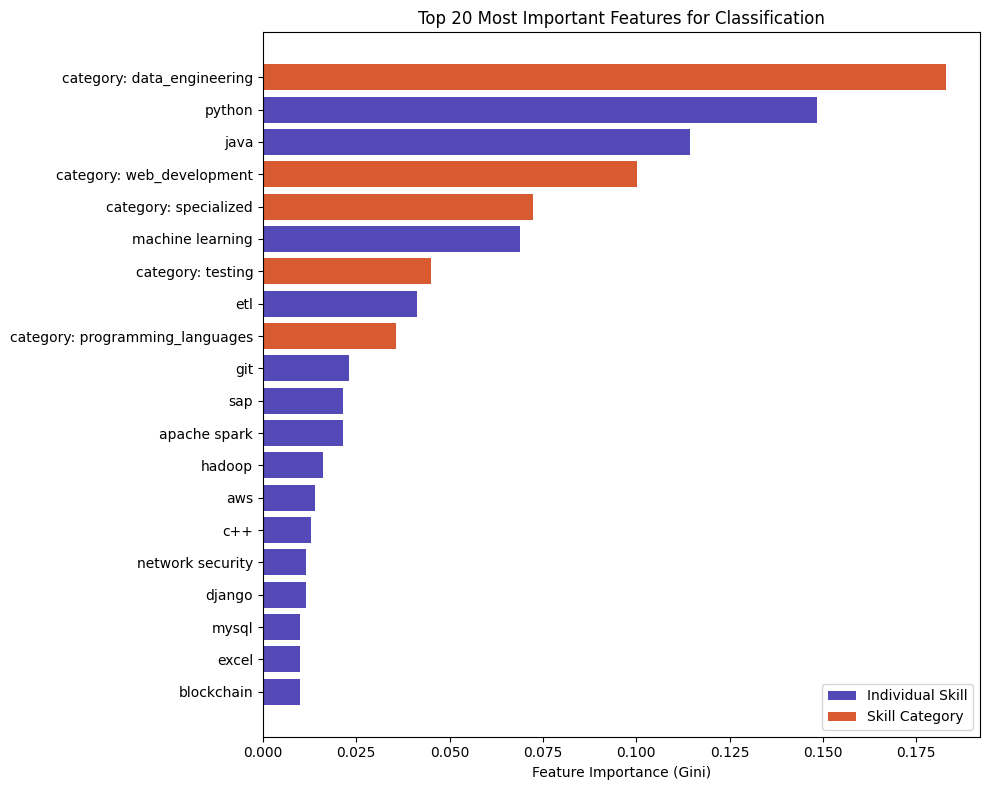

Top 10 discriminative features:
  CAT: data_engineering: 0.1829
  python: 0.1485
  java: 0.1145
  CAT: web_development: 0.1003
  CAT: specialized: 0.0723
  machine learning: 0.0688
  CAT: testing: 0.0450
  etl: 0.0413
  CAT: programming_languages: 0.0357
  git: 0.0232


In [14]:
# ============================================================
# 5. Feature Importance Analysis (Decision Tree)
# ============================================================

importances = dt_best.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names_combined,
    'importance': importances,
}).sort_values('importance', ascending=False)

# Top 20 most important features
top_features = feature_importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#534AB7' if f.startswith('skill_') else '#D85A30' for f in top_features['feature']]
ax.barh(range(len(top_features)), top_features['importance'].values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f.replace('skill_', '').replace('cat_', 'category: ') for f in top_features['feature']])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 20 Most Important Features for Classification')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#534AB7', label='Individual Skill'),
                   Patch(facecolor='#D85A30', label='Skill Category')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 discriminative features:")
for _, row in top_features.head(10).iterrows():
    print(f"  {row['feature'].replace('skill_', '').replace('cat_', 'CAT: ')}: "
          f"{row['importance']:.4f}")


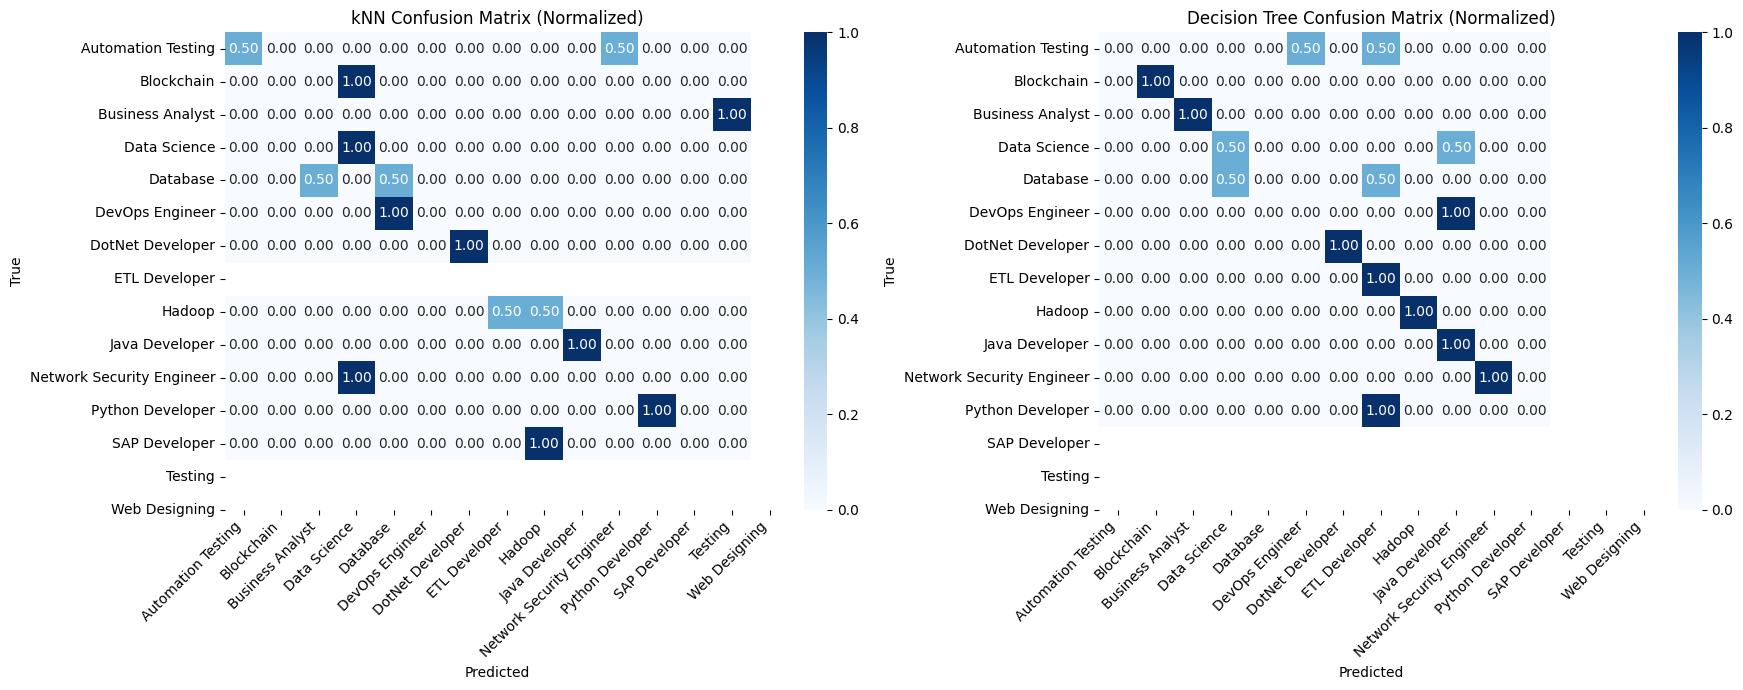

In [15]:
# ============================================================
# 6. Confusion Matrix Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, y_pred) in zip(axes, [('kNN', y_val_pred_knn), ('Decision Tree', y_val_pred_dt)]):
    cm = confusion_matrix(y_val, y_pred)
    # Normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues', ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{name} Confusion Matrix (Normalized)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('outputs/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


Running 5-fold cross-validation comparison...
Using KFold (smallest class has 3 samples, too few for stratified)

kNN (combined features):
  F1 scores: [0.3914 0.437  0.5444 0.5685 0.2741]
  Mean: 0.4431 ± 0.1070

Decision Tree:
  F1 scores: [0.1444 0.4815 0.3148 0.4722 0.2852]
  Mean: 0.3396 ± 0.1260

Paired t-test (kNN (combined features) vs Decision Tree):
  t-statistic: 1.7297
  p-value: 0.1587
  Significant difference (p<0.05): No


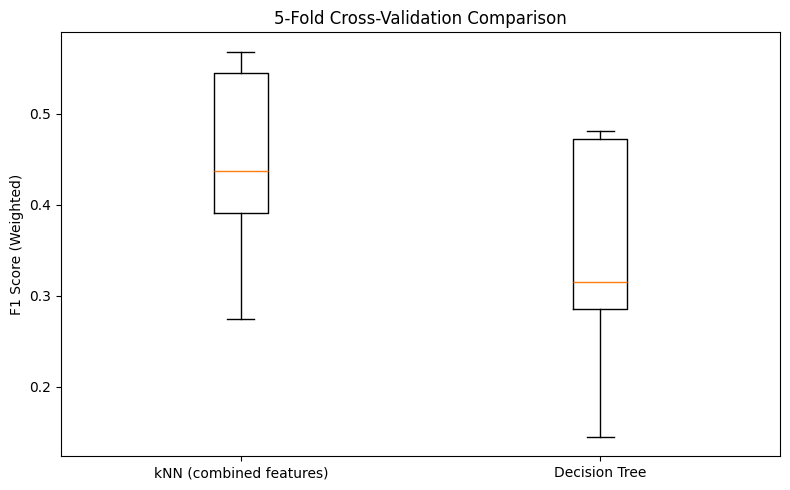

In [16]:
# ============================================================
# 7. Cross-Validation Comparison
# ============================================================

print("Running 5-fold cross-validation comparison...")
print("="*60)

# Combine train+val for final CV comparison
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# Use regular KFold if StratifiedKFold fails on rare classes
from sklearn.model_selection import KFold
min_class_count = min(Counter(y_trainval).values())
if min_class_count >= 5:
    cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print("Using StratifiedKFold (5 folds)")
else:
    cv_final = KFold(n_splits=5, shuffle=True, random_state=42)
    print(f"Using KFold (smallest class has {min_class_count} samples, too few for stratified)")

models = {
    'kNN (combined features)': KNeighborsClassifier(**grid_search.best_params_),
    'Decision Tree': DecisionTreeClassifier(**dt_grid.best_params_, random_state=42),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv_final, scoring='f1_weighted')
    cv_results[name] = scores
    print(f"\n{name}:")
    print(f"  F1 scores: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f} ± {scores.std():.4f}")

# Statistical comparison
from scipy import stats
if len(cv_results) >= 2:
    names = list(cv_results.keys())
    scores_1 = cv_results[names[0]]
    scores_2 = cv_results[names[1]]
    t_stat, p_value = stats.ttest_rel(scores_1, scores_2)
    print(f"\nPaired t-test ({names[0]} vs {names[1]}):")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant difference (p<0.05): {'Yes' if p_value < 0.05 else 'No'}")

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_ylabel('F1 Score (Weighted)')
ax.set_title('5-Fold Cross-Validation Comparison')
plt.tight_layout()
plt.savefig('outputs/05_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


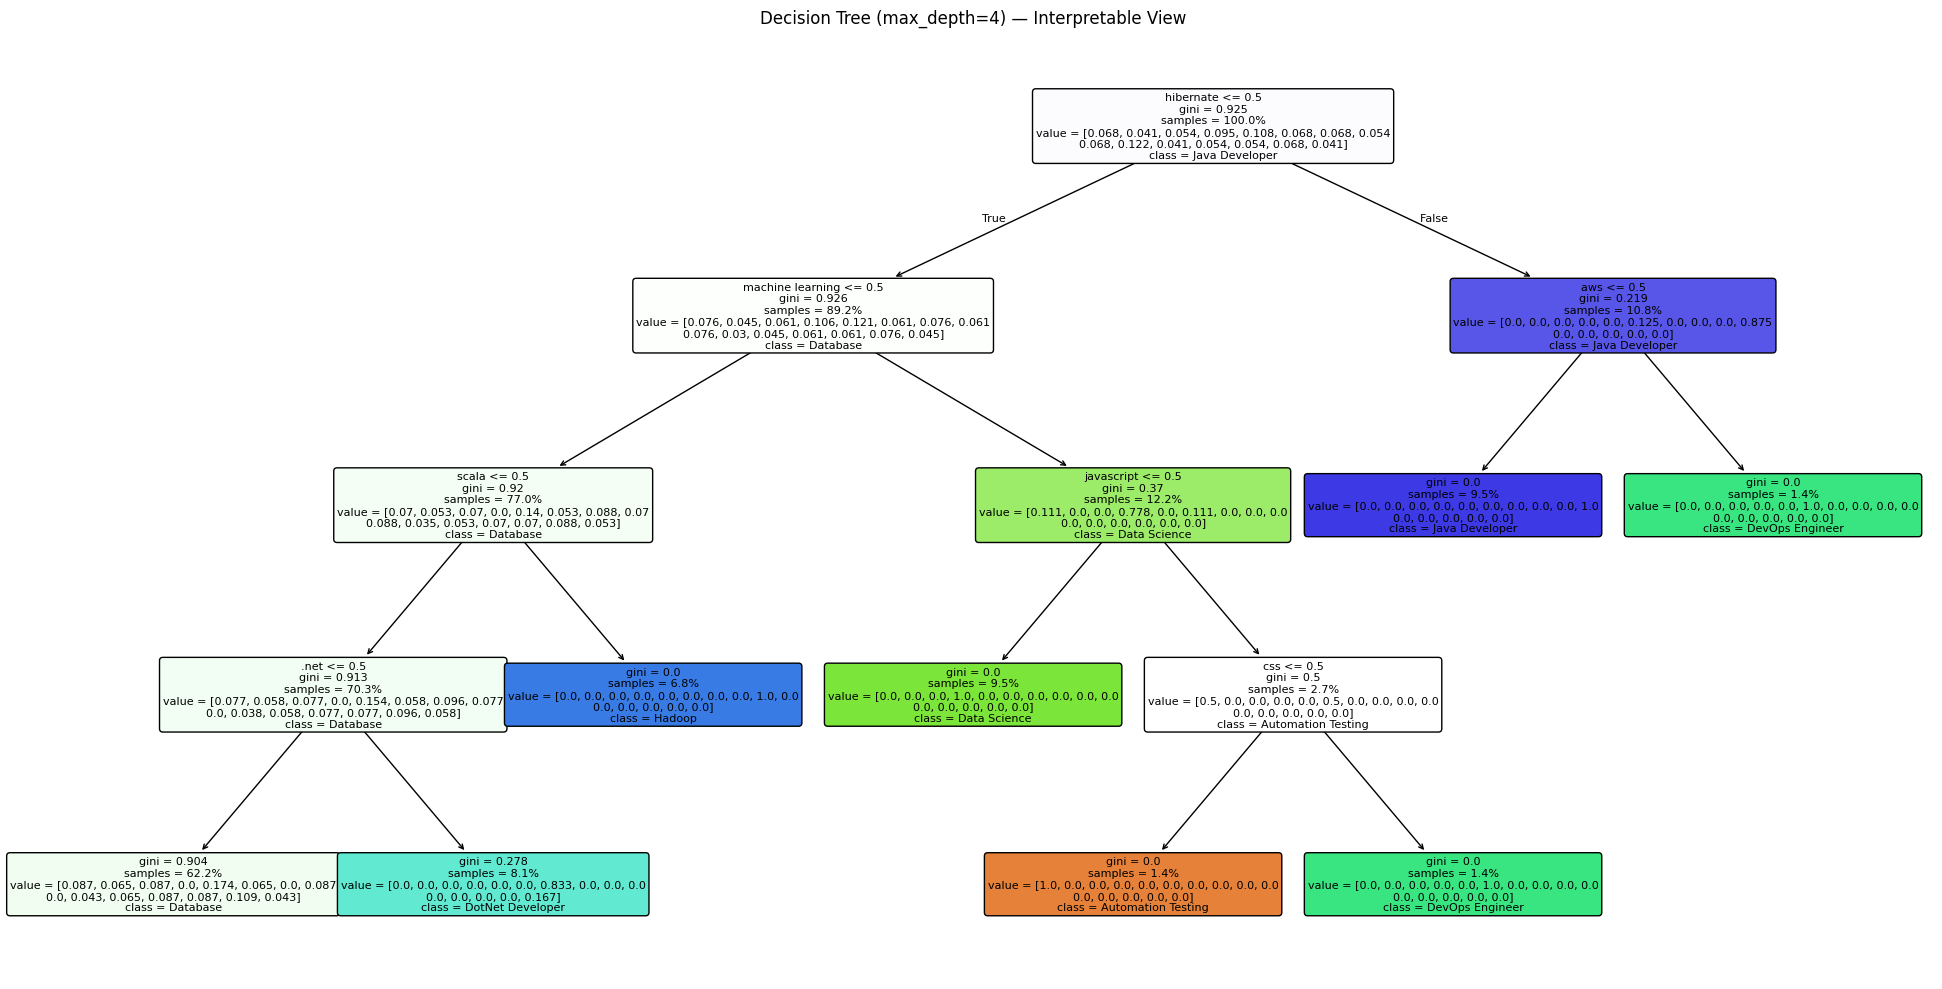

Decision Tree Rules (depth=4):
|--- hibernate <= 0.50
|   |--- machine learning <= 0.50
|   |   |--- scala <= 0.50
|   |   |   |--- .net <= 0.50
|   |   |   |   |--- class: Database
|   |   |   |--- .net >  0.50
|   |   |   |   |--- class: DotNet Developer
|   |   |--- scala >  0.50
|   |   |   |--- class: Hadoop
|   |--- machine learning >  0.50
|   |   |--- javascript <= 0.50
|   |   |   |--- class: Data Science
|   |   |--- javascript >  0.50
|   |   |   |--- css <= 0.50
|   |   |   |   |--- class: Automation Testing
|   |   |   |--- css >  0.50
|   |   |   |   |--- class: DevOps Engineer
|--- hibernate >  0.50
|   |--- aws <= 0.50
|   |   |--- class: Java Developer
|   |--- aws >  0.50
|   |   |--- class: DevOps Engineer



In [17]:
# ============================================================
# 8. Decision Tree Visualization (Pruned for readability)
# ============================================================

# Train a shallow tree for visualization
dt_viz = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_viz, feature_names=[f.replace('skill_', '').replace('cat_', 'CAT:')
                                  for f in feature_names_combined],
          class_names=class_names, filled=True, rounded=True,
          fontsize=8, ax=ax, proportion=True)
ax.set_title('Decision Tree (max_depth=4) — Interpretable View')
plt.tight_layout()
plt.savefig('outputs/05_decision_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()

# Text representation
print("Decision Tree Rules (depth=4):")
print(export_text(dt_viz, feature_names=[f.replace('skill_', '').replace('cat_', 'CAT:')
                                          for f in feature_names_combined],
                  class_names=list(class_names), max_depth=3))


In [18]:
# ============================================================
# 9. Final Test Set Evaluation
# ============================================================

print("="*60)
print("FINAL TEST SET RESULTS")
print("="*60)

# Retrain on train+val, evaluate on test
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

knn_final = KNeighborsClassifier(**grid_search.best_params_)
knn_final.fit(X_trainval, y_trainval)
y_test_pred_knn = knn_final.predict(X_test)

dt_final = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
dt_final.fit(X_trainval, y_trainval)
y_test_pred_dt = dt_final.predict(X_test)

results_summary = {}
for name, y_pred in [('kNN', y_test_pred_knn), ('Decision Tree', y_test_pred_dt)]:
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    results_summary[name] = {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec}
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")

# Save models and results
with open('models/knn_final.pkl', 'wb') as f:
    pickle.dump(knn_final, f)
with open('models/dt_final.pkl', 'wb') as f:
    pickle.dump(dt_final, f)
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open('data/processed/baseline_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
with open('data/processed/feature_importance.csv', 'w') as f:
    feature_importance_df.to_csv(f, index=False)

print(f"\n✅ Models and results saved!")
print(f"\n{'='*60}")
print("PHASE 3b COMPLETE — Ready for Notebook 06: Evaluation")
print(f"{'='*60}")


FINAL TEST SET RESULTS

kNN:
  Accuracy:  0.5625
  F1:        0.5062
  Precision: 0.4792
  Recall:    0.5625

Decision Tree:
  Accuracy:  0.3125
  F1:        0.2500
  Precision: 0.2500
  Recall:    0.3125

✅ Models and results saved!

PHASE 3b COMPLETE — Ready for Notebook 06: Evaluation
